<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [2]:
def min_max(X):
  return (X-np.min(X,axis=0)/(np.max(X,axis=0)-np.min(X,axis=0)))

def standardize(X):
  return (X-np.mean(X,axis=0))/np.std(X,axis=0)


In [5]:
X=np.array([2,144,12,13,4])

print(standardize(X))

[-0.60362263  1.99378384 -0.42070668 -0.40241509 -0.56703944]


In [16]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

X=np.array([[10],[20],[30],[40]])

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

scaler_2=MinMaxScaler()
X_scaled_2=scaler_2.fit_transform(X)


print(X_scaled," ",X_scaled_2)

[[-1.34164079]
 [-0.4472136 ]
 [ 0.4472136 ]
 [ 1.34164079]]   [[0.        ]
 [0.33333333]
 [0.66666667]
 [1.        ]]


In [17]:
#Comparing rate of convergence with and without scaling.

In [19]:
import matplotlib.pyplot as plt

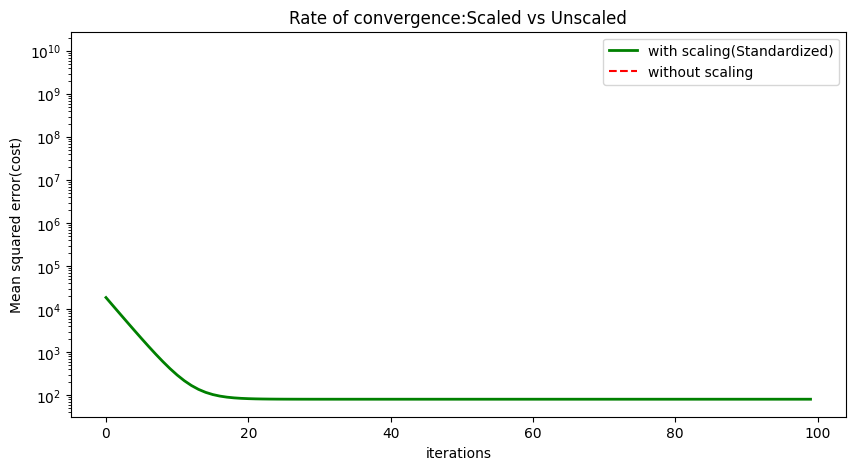

In [22]:
np.random.seed(42)
X=100*np.random.rand(100,1)
Y=3*X+5+10*np.random.randn(100,1)

x_mean,x_std=np.mean(X),np.std(X)

X_scaled=(X-x_mean)/x_std

def train_manual(X_data,y_target,lr=0.1,iterations=100):
  m=len(y_target)
  theta=np.zeros((2,1))
  X_b=np.c_[np.ones((100,1)),X_data]
  cost_history=[]

  for i in range(iterations):
    gradients=(2/m)*X_b.T.dot(X_b.dot(theta)-y_target)
    theta=theta-lr*gradients
    cost=np.mean((X_b.dot(theta)-y_target)**2)
    cost_history.append(cost)

    if cost>1e10:
      break

  return cost_history



history_unscaled=train_manual(X,Y,0.1,100)
history_scaled=train_manual(X_scaled,Y,0.1,100)

plt.figure(figsize=(10,5))
plt.plot(history_scaled,label="with scaling(Standardized)",color='green',linewidth=2)
plt.plot(history_unscaled,label="without scaling",color='red',linestyle='--')
plt.xlabel("iterations")
plt.ylabel("Mean squared error(cost)")
plt.title("Rate of convergence:Scaled vs Unscaled")
plt.yscale('log')
plt.legend()
plt.show()

